In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## LOADING THE DATASET

In [4]:
load_data = pd.read_csv(r"D:\Datasets\house price prediction advanced\AmesHousing.csv")
#Remove leading/trailing spaces from columns
load_data.columns=load_data.columns.str.strip()

In [5]:
load_data.head(5)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [6]:
load_data.keys()


Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [7]:
print(load_data.Alley)

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
2925    NaN
2926    NaN
2927    NaN
2928    NaN
2929    NaN
Name: Alley, Length: 2930, dtype: object


In [8]:
print(load_data.SalePrice)

0       215000
1       105000
2       172000
3       244000
4       189900
         ...  
2925    142500
2926    131000
2927    132000
2928    170000
2929    188000
Name: SalePrice, Length: 2930, dtype: int64


In [9]:
type(load_data)

pandas.core.frame.DataFrame

In [10]:
load_data.columns


Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [11]:
load_data.shape

(2930, 82)

In [12]:
load_data.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [13]:
load_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [14]:
#Better way to see the missing values
load_data.isnull().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

In [15]:
missing = load_data.isnull().sum()
missing = missing[missing > 0]

print(missing)

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64


In [16]:
missing_percent = load_data.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

Pool QC           99.556314
Misc Feature      96.382253
Alley             93.242321
Fence             80.477816
Mas Vnr Type      60.580205
                    ...    
Mo Sold            0.000000
Yr Sold            0.000000
Sale Type          0.000000
Sale Condition     0.000000
SalePrice          0.000000
Length: 82, dtype: float64

In [17]:
load_data.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [18]:
#renames SalePrice as Price(last 2nd column)
load_data['Price']=load_data.SalePrice

In [19]:
load_data.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,Price
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,NaN,NaN,NaN,0,5,2010,WD,Normal,215000,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,NaN,NaN,NaN,0,4,2010,WD,Normal,244000,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900,189900


In [20]:
#deleting the order index
load_data.drop('Order', axis =1, inplace=True)

In [21]:
load_data.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,Price
0,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2010,WD,Normal,215000,215000
1,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000,105000
2,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000,172000
3,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,4,2010,WD,Normal,244000,244000
4,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900,189900


In [22]:
load_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2930 non-null   int64  
 1   MS SubClass      2930 non-null   int64  
 2   MS Zoning        2930 non-null   object 
 3   Lot Frontage     2440 non-null   float64
 4   Lot Area         2930 non-null   int64  
 5   Street           2930 non-null   object 
 6   Alley            198 non-null    object 
 7   Lot Shape        2930 non-null   object 
 8   Land Contour     2930 non-null   object 
 9   Utilities        2930 non-null   object 
 10  Lot Config       2930 non-null   object 
 11  Land Slope       2930 non-null   object 
 12  Neighborhood     2930 non-null   object 
 13  Condition 1      2930 non-null   object 
 14  Condition 2      2930 non-null   object 
 15  Bldg Type        2930 non-null   object 
 16  House Style      2930 non-null   object 
 17  Overall Qual  

In [23]:
load_data.describe()

,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice,Price
count,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,2929.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,442.629566,...,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068,180796.060068
std,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,455.590839,...,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357,79886.692357
min,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000,12789.000000
25%,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000,129500.000000
50%,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,...,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000,160000.000000
75%,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,734.000000,...,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000,213500.000000
max,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000,755000.000000


In [24]:
missing = load_data.isnull().sum()
missing = missing[missing > 0]
print(missing)

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64


In [25]:
#here we can see that in columns,ALLEY, POOL QC, FENCE, MISC FEATURE  has major missing 
#values, but in those columns missing means NO so we wil fill those with None
cols = ['Alley', 'Pool QC', 'Fence', 'Misc Feature']
load_data[cols] = load_data[cols].fillna('None')

In [26]:
load_data[cols].isnull().sum()

Alley           0
Pool QC         0
Fence           0
Misc Feature    0
dtype: int64

In [27]:
missing1 = load_data.isnull().sum()
missing1 = missing1[missing1 > 0]
print(missing1)

Lot Frontage       490
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
dtype: int64


In [28]:
#Handling numerical and categorical columns separately
num_cols = load_data.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

Index(['PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area',
       'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area',
       'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath',
       'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces',
       'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF',
       'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch',
       'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice', 'Price'],
      dtype='object')


In [29]:
cat_cols = load_data.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='object')


In [30]:
load_data[num_cols].isnull().sum()

PID                  0
MS SubClass          0
Lot Frontage       490
Lot Area             0
Overall Qual         0
Overall Cond         0
Year Built           0
Year Remod/Add       0
Mas Vnr Area        23
BsmtFin SF 1         1
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
1st Flr SF           0
2nd Flr SF           0
Low Qual Fin SF      0
Gr Liv Area          0
Bsmt Full Bath       2
Bsmt Half Bath       2
Full Bath            0
Half Bath            0
Bedroom AbvGr        0
Kitchen AbvGr        0
TotRms AbvGrd        0
Fireplaces           0
Garage Yr Blt      159
Garage Cars          1
Garage Area          1
Wood Deck SF         0
Open Porch SF        0
Enclosed Porch       0
3Ssn Porch           0
Screen Porch         0
Pool Area            0
Misc Val             0
Mo Sold              0
Yr Sold              0
SalePrice            0
Price                0
dtype: int64

In [31]:
load_data[cat_cols].isnull().sum()

MS Zoning            0
Street               0
Alley                0
Lot Shape            0
Land Contour         0
Utilities            0
Lot Config           0
Land Slope           0
Neighborhood         0
Condition 1          0
Condition 2          0
Bldg Type            0
House Style          0
Roof Style           0
Roof Matl            0
Exterior 1st         0
Exterior 2nd         0
Mas Vnr Type      1775
Exter Qual           0
Exter Cond           0
Foundation           0
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin Type 2      81
Heating              0
Heating QC           0
Central Air          0
Electrical           1
Kitchen Qual         0
Functional           0
Fireplace Qu      1422
Garage Type        157
Garage Finish      159
Garage Qual        159
Garage Cond        159
Paved Drive          0
Pool QC              0
Fence                0
Misc Feature         0
Sale Type            0
Sale Condition       0
dtype: int6

In [32]:
#filling the missing values to make the data consistent
cat_cols = load_data.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='object')


In [33]:
num_cols = load_data.select_dtypes(include=['int64','float64']).columns
print(num_cols)

Index(['PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area',
       'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area',
       'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath',
       'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces',
       'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF',
       'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch',
       'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice', 'Price'],
      dtype='object')


### Exploratory Data Analysis


In [34]:
# correlation
load_data[num_cols].corr()

,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice,Price
PID,1.000000,-0.001281,-0.096918,0.034868,-0.263147,0.104451,-0.343388,-0.157111,-0.229283,-0.098375,...,-0.071311,0.162519,-0.024894,-0.025735,-0.002845,-0.008260,-0.050455,0.009579,-0.246521,-0.246521
MS SubClass,-0.001281,1.000000,-0.420135,-0.204613,0.039419,-0.067349,0.036579,0.043397,0.002730,-0.060075,...,-0.014823,-0.022866,-0.037956,-0.050614,-0.003434,-0.029254,0.000350,-0.017905,-0.085092,-0.085092
Lot Frontage,-0.096918,-0.420135,1.000000,0.491313,0.212042,-0.074448,0.121562,0.091712,0.222407,0.215583,...,0.163040,0.012758,0.028564,0.076666,0.173947,0.044476,0.011085,-0.007547,0.357318,0.357318
Lot Area,0.034868,-0.204613,0.491313,1.000000,0.097188,-0.034759,0.023258,0.021682,0.126830,0.191555,...,0.103760,0.021868,0.016243,0.055044,0.093775,0.069188,0.003859,-0.023085,0.266549,0.266549
Overall Qual,-0.263147,0.039419,0.212042,0.097188,1.000000,-0.094812,0.597027,0.569609,0.429418,0.284118,...,0.298412,-0.140332,0.018240,0.041615,0.030399,0.005179,0.031103,-0.020719,0.799262,0.799262
Overall Cond,0.104451,-0.067349,-0.074448,-0.034759,-0.094812,1.000000,-0.368773,0.047680,-0.135340,-0.050935,...,-0.068934,0.071459,0.043852,0.044055,-0.016787,0.034056,-0.007295,0.031207,-0.101697,-0.101697
Year Built,-0.343388,0.036579,0.121562,0.023258,0.597027,-0.368773,1.000000,0.612095,0.313292,0.279870,...,0.198365,-0.374364,0.015803,-0.041436,0.002213,-0.011011,0.014577,-0.013197,0.558426,0.558426
Year Remod/Add,-0.157111,0.043397,0.091712,0.021682,0.569609,0.047680,0.612095,1.000000,0.196928,0.151790,...,0.241748,-0.220383,0.037412,-0.046888,-0.011410,-0.003132,0.018048,0.032652,0.532974,0.532974
Mas Vnr Area,-0.229283,0.002730,0.222407,0.126830,0.429418,-0.135340,0.313292,0.196928,1.000000,0.301872,...,0.143748,-0.110787,0.013778,0.065643,0.004617,0.044934,-0.000276,-0.017715,0.508285,0.508285
BsmtFin SF 1,-0.098375,-0.060075,0.215583,0.191555,0.284118,-0.050935,0.279870,0.151790,0.301872,1.000000,...,0.124947,-0.100455,0.050541,0.095874,0.084140,0.092886,-0.001155,0.022397,0.432914,0.432914


In [35]:
dataset= load_data.drop(columns=['SalePrice'])

In [36]:
dataset.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,Price
0,526301100,20,RL,141.0,31770,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,5,2010,WD,Normal,215000
1,526350040,20,RH,80.0,11622,Pave,None,Reg,Lvl,AllPub,...,0,None,MnPrv,None,0,6,2010,WD,Normal,105000
2,526351010,20,RL,81.0,14267,Pave,None,IR1,Lvl,AllPub,...,0,None,None,Gar2,12500,6,2010,WD,Normal,172000
3,526353030,20,RL,93.0,11160,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,4,2010,WD,Normal,244000
4,527105010,60,RL,74.0,13830,Pave,None,IR1,Lvl,AllPub,...,0,None,MnPrv,None,0,3,2010,WD,Normal,189900


In [37]:
num_cols = dataset.select_dtypes(include=['int64','float64']).columns
print(num_cols)

Index(['PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area',
       'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area',
       'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath',
       'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces',
       'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF',
       'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch',
       'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'Price'],
      dtype='object')


In [38]:
#filling the missing values to make the data consistent
cat_cols = dataset.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='object')


In [39]:
dataset[num_cols].corr()

,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Price
PID,1.000000,-0.001281,-0.096918,0.034868,-0.263147,0.104451,-0.343388,-0.157111,-0.229283,-0.098375,...,-0.051135,-0.071311,0.162519,-0.024894,-0.025735,-0.002845,-0.008260,-0.050455,0.009579,-0.246521
MS SubClass,-0.001281,1.000000,-0.420135,-0.204613,0.039419,-0.067349,0.036579,0.043397,0.002730,-0.060075,...,-0.017310,-0.014823,-0.022866,-0.037956,-0.050614,-0.003434,-0.029254,0.000350,-0.017905,-0.085092
Lot Frontage,-0.096918,-0.420135,1.000000,0.491313,0.212042,-0.074448,0.121562,0.091712,0.222407,0.215583,...,0.120084,0.163040,0.012758,0.028564,0.076666,0.173947,0.044476,0.011085,-0.007547,0.357318
Lot Area,0.034868,-0.204613,0.491313,1.000000,0.097188,-0.034759,0.023258,0.021682,0.126830,0.191555,...,0.157212,0.103760,0.021868,0.016243,0.055044,0.093775,0.069188,0.003859,-0.023085,0.266549
Overall Qual,-0.263147,0.039419,0.212042,0.097188,1.000000,-0.094812,0.597027,0.569609,0.429418,0.284118,...,0.255663,0.298412,-0.140332,0.018240,0.041615,0.030399,0.005179,0.031103,-0.020719,0.799262
Overall Cond,0.104451,-0.067349,-0.074448,-0.034759,-0.094812,1.000000,-0.368773,0.047680,-0.135340,-0.050935,...,0.020344,-0.068934,0.071459,0.043852,0.044055,-0.016787,0.034056,-0.007295,0.031207,-0.101697
Year Built,-0.343388,0.036579,0.121562,0.023258,0.597027,-0.368773,1.000000,0.612095,0.313292,0.279870,...,0.228964,0.198365,-0.374364,0.015803,-0.041436,0.002213,-0.011011,0.014577,-0.013197,0.558426
Year Remod/Add,-0.157111,0.043397,0.091712,0.021682,0.569609,0.047680,0.612095,1.000000,0.196928,0.151790,...,0.217857,0.241748,-0.220383,0.037412,-0.046888,-0.011410,-0.003132,0.018048,0.032652,0.532974
Mas Vnr Area,-0.229283,0.002730,0.222407,0.126830,0.429418,-0.135340,0.313292,0.196928,1.000000,0.301872,...,0.165467,0.143748,-0.110787,0.013778,0.065643,0.004617,0.044934,-0.000276,-0.017715,0.508285
BsmtFin SF 1,-0.098375,-0.060075,0.215583,0.191555,0.284118,-0.050935,0.279870,0.151790,0.301872,1.000000,...,0.224010,0.124947,-0.100455,0.050541,0.095874,0.084140,0.092886,-0.001155,0.022397,0.432914


In [40]:
#import seaborn as sns
#sns.pairplot(load_data)

Text(0, 0.5, 'Overall Qual')

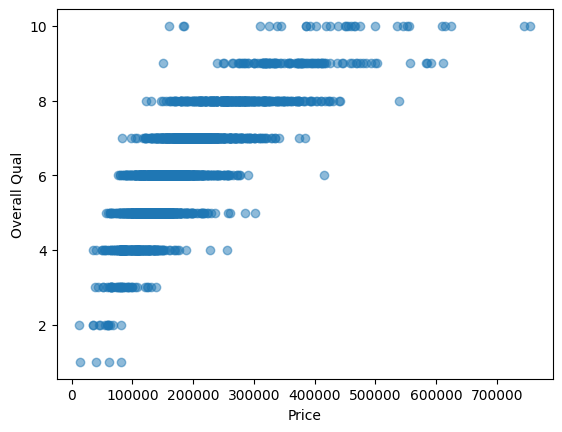

In [41]:
plt.scatter(dataset['Price'], dataset['Overall Qual'], alpha=0.5)
plt.xlabel('Price')
plt.ylabel('Overall Qual')

<Axes: xlabel='Price', ylabel='Overall Qual'>

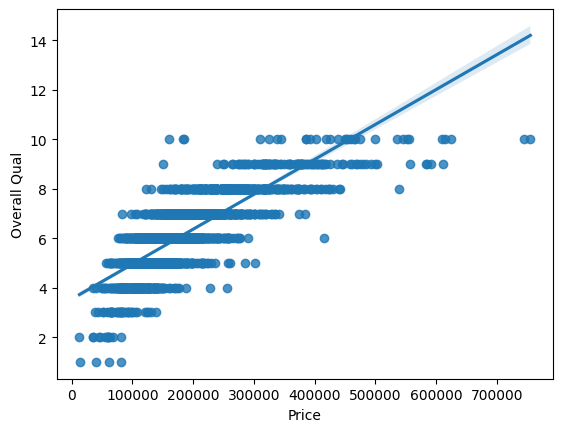

In [42]:
import seaborn as sns
sns.regplot(x='Price',y='Overall Qual', data = dataset)# poisitive correlation


<Axes: xlabel='Year Remod/Add', ylabel='Price'>

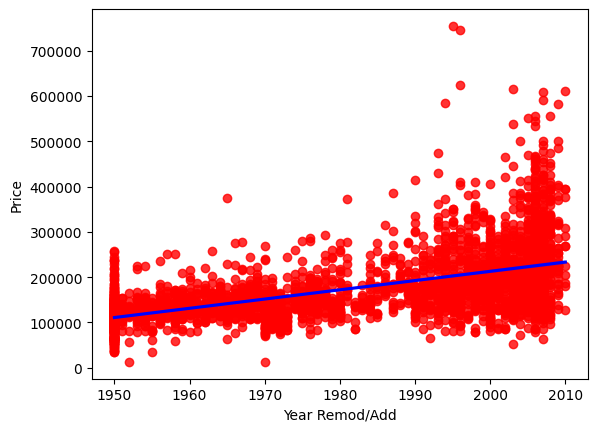

In [43]:
sns.regplot(x='Year Remod/Add',y='Price', data = dataset, color='red', line_kws={"color" : "blue"})

<Axes: xlabel='PID', ylabel='Price'>

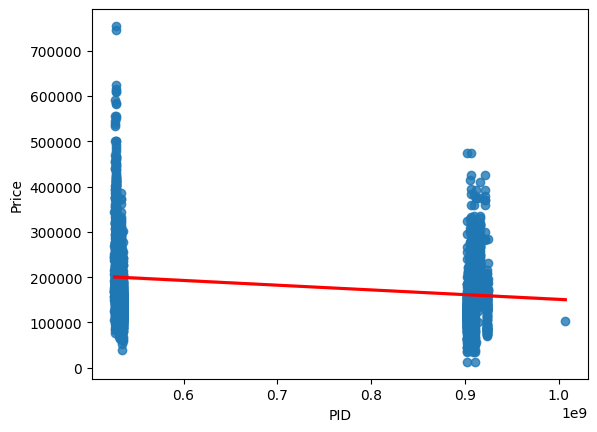

In [44]:
sns.regplot(x='PID',y='Price', data = dataset, line_kws={"color" : "red"})#small negative correlation


Load Data

↓

Train Test Split

↓

Handle Missing Values (fit on train only)

↓

Encode Categorical Variables

↓

Standardize

↓

Train Model

In [45]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2930 non-null   int64  
 1   MS SubClass      2930 non-null   int64  
 2   MS Zoning        2930 non-null   object 
 3   Lot Frontage     2440 non-null   float64
 4   Lot Area         2930 non-null   int64  
 5   Street           2930 non-null   object 
 6   Alley            2930 non-null   object 
 7   Lot Shape        2930 non-null   object 
 8   Land Contour     2930 non-null   object 
 9   Utilities        2930 non-null   object 
 10  Lot Config       2930 non-null   object 
 11  Land Slope       2930 non-null   object 
 12  Neighborhood     2930 non-null   object 
 13  Condition 1      2930 non-null   object 
 14  Condition 2      2930 non-null   object 
 15  Bldg Type        2930 non-null   object 
 16  House Style      2930 non-null   object 
 17  Overall Qual  

In [46]:
missing = dataset.isnull().sum()
missing = missing[missing > 0]
missing

Lot Frontage       490
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
dtype: int64

In [47]:
num_cols = dataset.select_dtypes(include=['int64','float64']).columns
num_cols

Index(['PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area',
       'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area',
       'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath',
       'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces',
       'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF',
       'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch',
       'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'Price'],
      dtype='object')

In [48]:
cat_cols = dataset.select_dtypes(include=['object','category']).columns
cat_cols

Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='object')

In [49]:
dataset[num_cols] = dataset[num_cols].fillna(dataset[num_cols].median())
num_cols.isnull().sum()

np.int64(0)

# ONE - hot encoding the categorical columns

In [50]:
# columns where NaN means feature does not exist
none_cols = [
'Alley','Mas Vnr Type','Bsmt Qual','Bsmt Cond','Bsmt Exposure',
'BsmtFin Type 1','BsmtFin Type 2','Fireplace Qu','Garage Type',
'Garage Finish','Garage Qual','Garage Cond','Pool QC','Fence','Misc Feature'
]
dataset[none_cols] = dataset[none_cols].fillna("None")


In [51]:
cat_cols=dataset.select_dtypes(include='object').columns
dataset[cat_cols] = dataset[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))
dataset = pd.get_dummies(dataset, columns=cat_cols, drop_first=True)

In [52]:
cat_cols.isnull().sum()

np.int64(0)

In [53]:
cat_cols

Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='object')

In [54]:
dataset['Price'] = np.log1p(dataset['Price'])# log transformation
X = dataset.drop("Price", axis=1)
y = dataset["Price"]

In [55]:
X.isnull().sum()

PID                       0
MS SubClass               0
Lot Frontage              0
Lot Area                  0
Overall Qual              0
                         ..
Sale Condition_AdjLand    0
Sale Condition_Alloca     0
Sale Condition_Family     0
Sale Condition_Normal     0
Sale Condition_Partial    0
Length: 276, dtype: int64

In [56]:
y.isnull().sum()

np.int64(0)

In [57]:
#Log transforming the target-> Improves the regression stability
dataset['Price'] = np.log1p(dataset['Price'])

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=43
)

In [60]:
X_train

,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
385,527366030,60,68.0,7500,8,5,2000,2001,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
1466,907265100,60,96.0,11690,8,5,1999,2000,192.0,0.0,...,False,False,False,False,True,False,False,False,True,False
2353,527365010,60,75.0,9512,7,5,2005,2006,0.0,788.0,...,False,True,False,False,False,False,False,False,False,True
942,911103050,50,105.0,8470,3,2,1915,1982,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1573,916380060,20,74.0,11563,8,5,2006,2007,258.0,1036.0,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2064,905201080,20,81.0,14175,5,5,1956,1998,0.0,386.0,...,False,False,False,False,True,False,False,False,True,False
2106,906380160,20,74.0,8556,7,5,2006,2006,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
2325,527166030,60,63.0,9084,7,5,1998,1998,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
2303,923400150,20,63.0,10712,5,5,1991,1992,0.0,212.0,...,False,False,True,False,False,False,False,False,False,False


In [61]:
y_train

385     12.301387
1466    12.240479
2353    12.592436
942     11.350418
1573    12.591338
          ...    
2064    12.138869
2106    12.175619
2325    12.081082
2303    11.445727
1860    12.829336
Name: Price, Length: 2344, dtype: float64

In [62]:
X_test

,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
1753,528275035,60,68.0,8063,6,5,2000,2000,0.0,0.0,...,False,False,False,False,True,False,False,False,False,False
2103,906380070,60,69.0,9588,8,5,2007,2007,270.0,0.0,...,False,True,False,False,False,False,False,False,False,True
2515,533242030,20,60.0,7180,8,5,2001,2002,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
669,535402330,90,91.0,11643,5,5,1969,1969,368.0,500.0,...,False,False,False,False,True,False,False,False,True,False
2679,903232170,50,52.0,6240,4,5,1947,1950,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,909176150,30,68.0,7890,6,6,1939,1950,0.0,238.0,...,False,False,False,False,True,False,False,False,True,False
27,527425090,20,70.0,10500,4,5,1971,1971,0.0,432.0,...,False,False,False,False,False,False,False,False,True,False
705,902201110,50,50.0,6000,5,7,1950,1970,0.0,384.0,...,False,False,False,False,True,False,False,False,True,False
2807,907405030,20,70.0,9135,6,5,2003,2003,120.0,340.0,...,False,False,False,False,True,False,False,False,True,False


In [63]:
y_test

1753    12.106258
2103    12.528160
2515    12.305923
669     12.206078
2679    11.296025
          ...    
289     11.744045
27      11.652696
705     11.771444
2807    12.206078
136     12.100718
Name: Price, Length: 586, dtype: float64

In [64]:
X_train

,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
385,527366030,60,68.0,7500,8,5,2000,2001,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
1466,907265100,60,96.0,11690,8,5,1999,2000,192.0,0.0,...,False,False,False,False,True,False,False,False,True,False
2353,527365010,60,75.0,9512,7,5,2005,2006,0.0,788.0,...,False,True,False,False,False,False,False,False,False,True
942,911103050,50,105.0,8470,3,2,1915,1982,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1573,916380060,20,74.0,11563,8,5,2006,2007,258.0,1036.0,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2064,905201080,20,81.0,14175,5,5,1956,1998,0.0,386.0,...,False,False,False,False,True,False,False,False,True,False
2106,906380160,20,74.0,8556,7,5,2006,2006,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
2325,527166030,60,63.0,9084,7,5,1998,1998,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
2303,923400150,20,63.0,10712,5,5,1991,1992,0.0,212.0,...,False,False,True,False,False,False,False,False,False,False


In [65]:
X_test

,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
1753,528275035,60,68.0,8063,6,5,2000,2000,0.0,0.0,...,False,False,False,False,True,False,False,False,False,False
2103,906380070,60,69.0,9588,8,5,2007,2007,270.0,0.0,...,False,True,False,False,False,False,False,False,False,True
2515,533242030,20,60.0,7180,8,5,2001,2002,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
669,535402330,90,91.0,11643,5,5,1969,1969,368.0,500.0,...,False,False,False,False,True,False,False,False,True,False
2679,903232170,50,52.0,6240,4,5,1947,1950,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,909176150,30,68.0,7890,6,6,1939,1950,0.0,238.0,...,False,False,False,False,True,False,False,False,True,False
27,527425090,20,70.0,10500,4,5,1971,1971,0.0,432.0,...,False,False,False,False,False,False,False,False,True,False
705,902201110,50,50.0,6000,5,7,1950,1970,0.0,384.0,...,False,False,False,False,True,False,False,False,True,False
2807,907405030,20,70.0,9135,6,5,2003,2003,120.0,340.0,...,False,False,False,False,True,False,False,False,True,False


# MODEL TRAINING

In [66]:
from sklearn.linear_model import LinearRegression

In [67]:
regression= LinearRegression()

In [68]:
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [69]:
print(regression.coef_)

[ 1.57269901e-10 -1.03086271e-04  3.73934773e-04  2.83052984e-06
  4.96466556e-02  4.26524904e-02  1.79771181e-03  5.88120666e-04
  2.18869743e-05  4.90612005e-05  5.15228758e-05 -2.02692659e-05
  8.03120386e-05  7.84535738e-05  5.90208941e-05  5.19272381e-05
  1.89409601e-04  1.90219391e-02 -2.64866127e-04  1.96111533e-02
  6.20892785e-03 -2.85749154e-03 -4.10897764e-02  5.76288285e-03
  1.71015804e-02  2.35302545e-04  2.69364742e-02  4.15243700e-05
  3.74359968e-05  1.08470288e-04  1.39784270e-04  9.55814066e-05
  2.14698351e-04 -3.18461231e-04 -1.97965756e-06 -1.81058090e-04
 -4.66921958e-03 -5.87975062e-01 -3.96440396e-01 -3.64969724e-01
 -3.35496288e-01 -3.84070456e-01 -4.59075366e-01  1.45947462e-01
 -2.19859742e-02 -4.06841524e-02  2.40938748e-02  7.02537428e-03
  5.56176835e-03  1.60152770e-02 -4.42213113e-03  1.34878039e-02
  2.91006802e-13 -1.08483241e-01  1.29561918e-02 -3.53079993e-02
  2.91316537e-03 -5.39009215e-03  2.44919023e-02 -6.04887996e-02
 -3.48671258e-03 -1.12801

In [70]:
print(regression.intercept_)

11.904592833424399


In [71]:
# on which parameters the model has been trained
regression.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [72]:
#Predicting with test data
reg_pred = regression.predict(X_test)
reg_pred

array([12.02672627, 12.67001927, 12.30945623, 12.13733909, 11.16050635,
       11.87644036, 11.928257  , 12.25300118, 11.8701105 , 11.41354564,
       11.60733779, 11.35501828, 11.88515814, 11.89110392, 11.816044  ,
       11.53599614, 12.30182575, 11.71491989, 11.83881562, 12.29496434,
       11.76711318, 11.54593404, 12.0387419 , 11.81115723, 12.26269479,
       12.05089935, 12.46485571, 11.72805321, 11.09286502, 12.61739719,
       11.77295866, 11.74228194, 12.09223685, 12.06637714, 11.965603  ,
       11.73607732, 11.87383185, 11.81009239, 12.16008409, 12.04905864,
       12.57411192, 11.90150075, 12.69913832, 11.80814879, 12.57178851,
       11.89315928, 12.28202632, 12.31910155, 11.63759653, 11.87368794,
       11.72434031, 11.78789891, 11.90843921, 12.13396781, 11.90047396,
       11.55400396, 12.29735828, 11.22947884, 12.32141186, 11.62835039,
       11.76941321, 11.81307128, 11.68785435, 11.43779981, 11.75657283,
       12.4324435 , 11.42985911, 12.46524629, 11.9536957 , 11.57

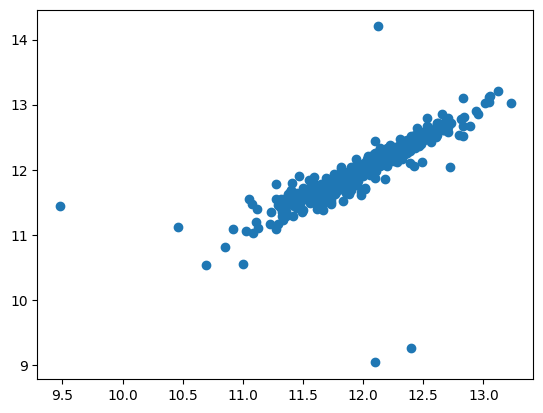

In [73]:
#plotting a scatter plot for the predicted data
plt.scatter(y_test, reg_pred)

In [74]:
## Calculating the errors
residuals = y_test - reg_pred
residuals

1753    0.079532
2103   -0.141860
2515   -0.003534
669     0.068739
2679    0.135519
          ...   
289     0.011928
27      0.230912
705     0.085682
2807   -0.062536
136    -0.335803
Name: Price, Length: 586, dtype: float64

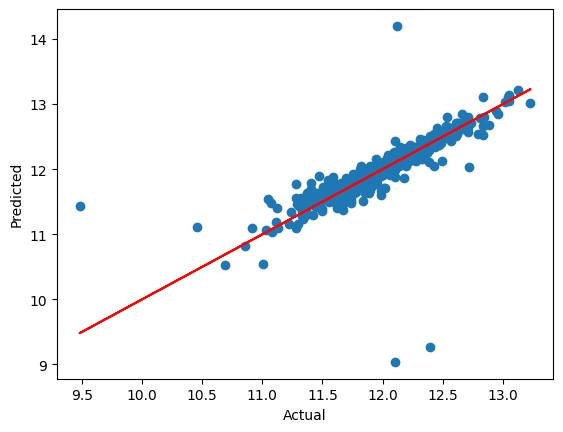

In [75]:
plt.scatter(y_test, reg_pred)
plt.plot(y_test, y_test, color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [76]:
from sklearn.metrics import r2_score
r2_score(y_test, reg_pred)

0.6176196952745787

In [77]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, reg_pred)

0.09788753125475552

In [78]:
print("R2:", r2_score(y_test, reg_pred))
print("MAE:", mean_absolute_error(y_test, reg_pred))

R2: 0.6176196952745787
MAE: 0.09788753125475552


# Improved Model Pipeline (Feature Engineering + Regularization)

In [79]:
# Feature Engineering
dataset['TotalSF'] = dataset['Total Bsmt SF'] + dataset['1st Flr SF'] + dataset['2nd Flr SF']
dataset['HouseAge'] = dataset['Yr Sold'] - dataset['Year Built']
dataset['RemodelAge'] = dataset['Yr Sold'] - dataset['Year Remod/Add']

dataset['TotalBathrooms'] = (
    dataset['Full Bath']+
    0.5 * dataset['Half Bath'] +
    dataset['Bsmt Full Bath'] +
    0.5 * dataset['Bsmt Half Bath']
)

dataset['TotalPorchSF'] = (
    dataset['Open Porch SF'] +
    dataset['3Ssn Porch'] +
    dataset['Enclosed Porch'] +
    dataset['Screen Porch']
)

In [80]:
# Adding a Preprocessing Pipeling
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', 'passthrough', cat_cols)
    ]
)

In [81]:
#Adding the regularized model
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RidgeCV(alphas=[1e-3, 1e-2, 1e-1, 1]))
])

In [82]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV

ridgecv = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=[0.01,0.1,1,10,100]))
])

In [83]:
ridgecv.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.","[0.01, 0.1, ...]"
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, 

In [84]:
y_pred = ridgecv.predict(X_test)

In [85]:
print(y_test.head())

1753    12.106258
2103    12.528160
2515    12.305923
669     12.206078
2679    11.296025
Name: Price, dtype: float64


In [86]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred)
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

mae = mean_absolute_error(y_test_actual, y_pred_actual)

print("R2:", r2)
print("MAE:", mae)

R2: 0.8468913176978392
MAE: 15399.343564957177


In [87]:
print(ridgecv.named_steps['model'])

RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])


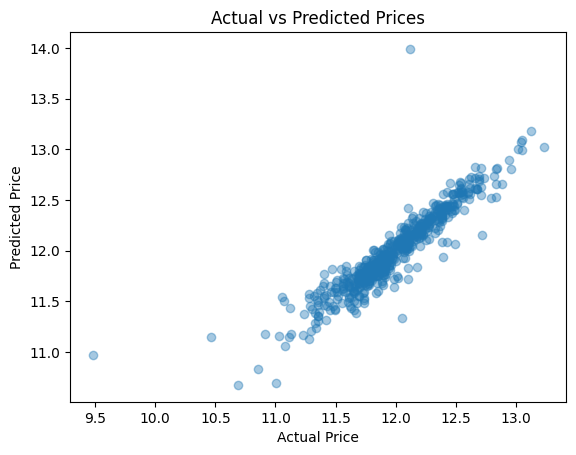

In [88]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

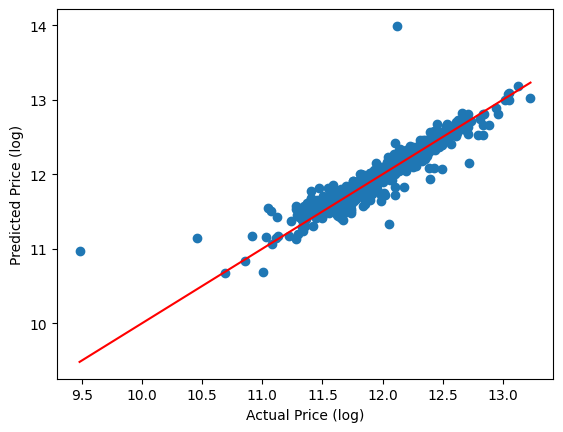

In [89]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price (log)")
plt.ylabel("Predicted Price (log)")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

In [90]:
errors = abs(y_test - y_pred)
largest_errors = errors.sort_values(ascending=False).head(5)

print(largest_errors)

2180    1.868595
1553    1.490349
1566    0.714664
726     0.681740
1014    0.567629
Name: Price, dtype: float64


# Identifying the Outliers

In [91]:
errors = abs(y_test - y_pred)

largest_errors = errors.sort_values(ascending=False).head(10)

print(largest_errors)

2180    1.868595
1553    1.490349
1566    0.714664
726     0.681740
1014    0.567629
767     0.490223
1401    0.453994
1949    0.430846
716     0.426877
2765    0.386021
Name: Price, dtype: float64


In [92]:
X_test.loc[largest_errors.index]

,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
2180,908154195,20,128.0,39290,10,5,2008,2009,1224.0,4010.0,...,False,True,False,False,False,False,False,False,False,True
1553,910251050,20,80.0,14584,1,5,1952,1952,0.0,0.0,...,False,False,False,False,True,False,False,False,False,False
1566,914475020,80,76.0,9880,6,6,1977,1977,0.0,522.0,...,False,False,False,False,True,False,False,False,True,False
726,902477120,30,60.0,7879,4,5,1920,1950,0.0,495.0,...,False,False,False,False,True,False,False,False,False,False
1014,527252080,120,60.0,8118,9,5,2007,2007,178.0,1034.0,...,False,False,False,False,True,False,False,False,True,False
767,904351240,50,60.0,9780,5,3,1934,1950,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
1401,905401045,20,73.0,39104,7,7,1954,2005,0.0,226.0,...,False,False,False,False,True,False,False,False,True,False
1949,535379060,30,60.0,10800,4,6,1927,2007,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
716,902326030,70,65.0,11700,7,7,1880,2003,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
2765,906475050,80,68.0,21453,6,5,1969,1969,0.0,938.0,...,False,False,False,False,True,False,False,False,True,False


In [93]:
#Plotting the gaussian curve
residuals = y_test - y_pred


Text(0, 0.5, 'Frequency')

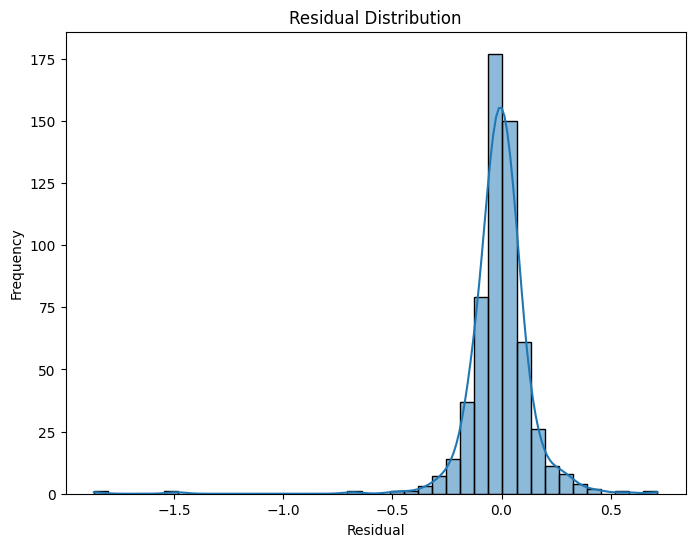

In [94]:
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=40)

plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")

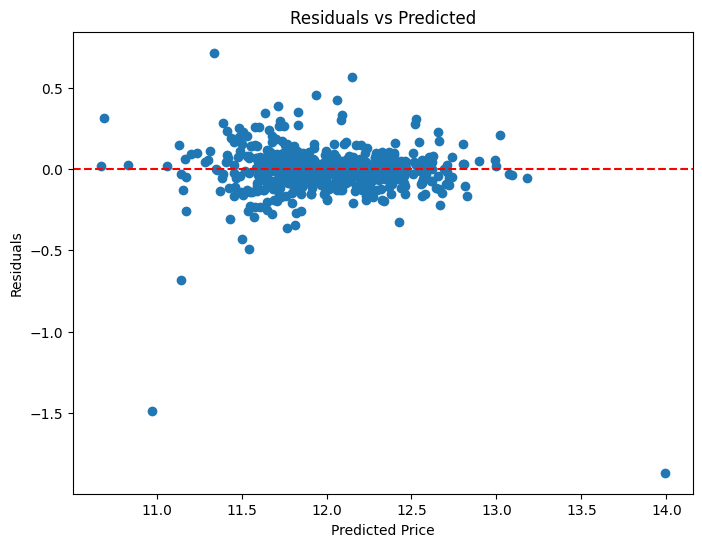

In [95]:
#Residual vs predicted
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residuals vs Predicted")

plt.show()

In [96]:
largest_residuals = abs(residuals).sort_values(ascending=False).head(10)

print(largest_residuals)

2180    1.868595
1553    1.490349
1566    0.714664
726     0.681740
1014    0.567629
767     0.490223
1401    0.453994
1949    0.430846
716     0.426877
2765    0.386021
Name: Price, dtype: float64


# #Professional Residual Diagnostic

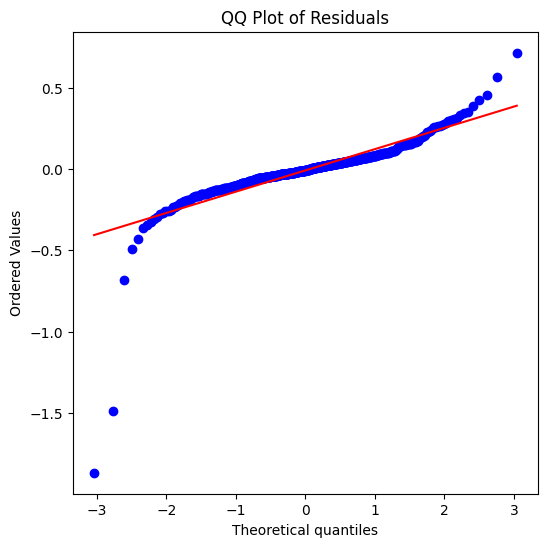

In [97]:
import scipy.stats as stats

plt.figure(figsize=(6,6))

stats.probplot(residuals, dist="norm", plot=plt)

plt.title("QQ Plot of Residuals")

plt.show()
#If points follow the straight line → residuals are approximately Gaussian.

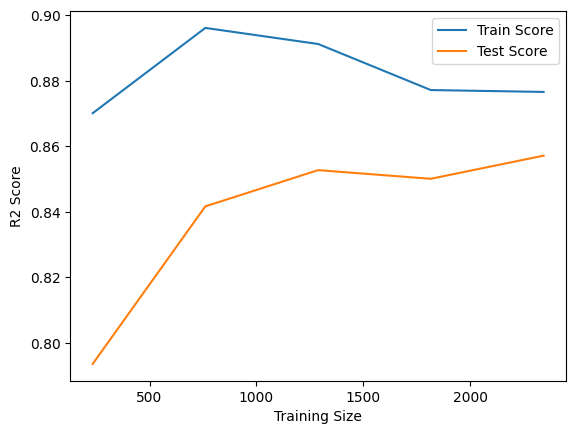

In [98]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    pipeline, X, y, cv=5, scoring="r2"
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Train Score")
plt.plot(train_sizes, test_mean, label="Test Score")

plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.legend()

# New Data Prediction

In [99]:
#USING AN EXISTING ROW FROM THE DATASET
sample = X_test.iloc[[0]]
print(sample)

            PID  MS SubClass  Lot Frontage  Lot Area  Overall Qual  \
1753  528275035           60          68.0      8063             6   

      Overall Cond  Year Built  Year Remod/Add  Mas Vnr Area  BsmtFin SF 1  \
1753             5        2000            2000           0.0           0.0   

      ...  Sale Type_ConLw  Sale Type_New  Sale Type_Oth  Sale Type_VWD  \
1753  ...            False          False          False          False   

      Sale Type_WD   Sale Condition_AdjLand  Sale Condition_Alloca  \
1753           True                   False                  False   

      Sale Condition_Family  Sale Condition_Normal  Sale Condition_Partial  
1753                  False                  False                   False  

[1 rows x 276 columns]


In [100]:
log_prediction = ridgecv.predict(sample)
log_prediction

array([12.02000924])

In [101]:
import numpy as np

predicted_price = np.expm1(log_prediction)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 166043.18983372842


In [102]:
actual_price = np.expm1(y_test.iloc[0])
print("Actual Price: ", actual_price)
print("Predicted Price: ", predicted_price[0])

Actual Price:  181000.00000000006
Predicted Price:  166043.18983372842


# Implementing  SVR

In [103]:
from sklearn.svm import SVR

In [104]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(kernel="rbf", C=50, gamma=0.0001, epsilon=0.01))
])

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

param_grid = {
    "model__C":[10,50,100],
    "model__gamma":[0.0001,0.001,0.01],
    "model__epsilon":[0.0001,0.001,0.01]
}

grid = GridSearchCV(svr_pipeline, param_grid, cv=5)

grid.fit(X_train, y_train)

print(grid.best_params_)

In [105]:
svr_pipeline.fit(X_train, y_train)
y_pred = svr_pipeline.predict(X_test)

In [106]:
print("R2:", r2_score(y_test, y_pred))

y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

print("MAE:", mean_absolute_error(y_test_actual, y_pred_actual))

R2: 0.8653019248858869
MAE: 13605.280772935781


# Implementing XGBoost Regressor

In [106]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid = {
    "n_estimators":[500,800,1000],
    "max_depth":[3,4,5],
    "learning_rate":[0.01,0.03,0.05],
    "subsample":[0.7,0.8,1],
    "colsample_bytree":[0.7,0.8,1]
}

xgb = XGBRegressor(random_state=42)

grid = GridSearchCV(
    xgb,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 0.7}


In [107]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

In [108]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2:", r2_score(y_test, y_pred))

y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

print("MAE:", mean_absolute_error(y_test_actual, y_pred_actual))

R2: 0.9015305689694779
MAE: 12231.805814046505


# Saving the models to pkl file for deployment

In [114]:
import pickle
models = {
    "xgb" : xgb_model
}

with open("price_models.pkl","wb") as f:
    pickle.dump(models, f)

In [116]:
model.predict(X_test[:10])

array([171682.94, 320479.9 , 232038.06, 168538.34,  79558.3 , 139385.25,
       149382.39, 218622.62, 137456.88,  82373.54], dtype=float32)

In [118]:
import pickle
import sys

def identity(x):
    return x

sys.modules['__main__'].identity = identity

model = pickle.load(open("xgb_model.pkl","rb"))
print(model)

TransformedTargetRegressor(func=<function identity at 0x000001FAE37450C0>,
                           inverse_func=<ufunc 'expm1'>,
                           regressor=XGBRegressor(base_score=None, booster=None,
                                                  callbacks=None,
                                                  colsample_bylevel=None,
                                                  colsample_bynode=None,
                                                  colsample_bytree=0.7,
                                                  device=None,
                                                  early_stopping_rounds=None,
                                                  enable_categorical=False,
                                                  eval_metric=None,
                                                  feature_types=None,
                                                  feature_weights=None,
                                                  gamma=None, grow_policy=N